Audio Deepfake Detection System
Hybrid CNN + XGBoost Model

Splitting dataset into train/val/test...
Splits generated based on speaker identities:
Train: Real=10699, Fake=9810
Val: Real=595, Fake=378
Test: Real=8669, Fake=1628

Loading spectrograms...


Loading test/fake: 100%|██████████| 3323/3323 [00:07<00:00, 420.15it/s]



Dataset loaded:
  Training: (26008, 64, 79, 1)
  Validation: (8747, 64, 79, 1)
  Test: (13733, 64, 79, 1)

Training CNN model...
Epoch 1/15
407/407 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.6254 - loss: 0.7279 - val_accuracy: 0.7673 - val_loss: 0.5341 - learning_rate: 0.0010
Epoch 2/15
407/407 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.7575 - loss: 0.5184 - val_accuracy: 0.8096 - val_loss: 0.4332 - learning_rate: 0.0010
Epoch 3/15
407/407 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.8438 - loss: 0.3756 - val_accuracy: 0.8377 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 4/15
407/407 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.8778 - loss: 0.3019 - val_accuracy: 0.8963 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 5/15
407/407 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.8956 - loss: 0.2680 - val_accuracy: 0.9500 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 6/15
407/407 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9091 - loss: 0.2352 - val_accura

100%|██████████| 813/813 [00:20<00:00, 39.23it/s]


Extracting embeddings from 8747 samples...


100%|██████████| 274/274 [00:07<00:00, 39.07it/s]

Embedding dimension: (26008, 128)

Training XGBoost classifier...
[0]	validation_0-logloss:0.61249


[1]	validation_0-logloss:0.53996
[2]	validation_0-logloss:0.47993
[3]	validation_0-logloss:0.42997
[4]	validation_0-logloss:0.38691
[5]	validation_0-logloss:0.35023
[6]	validation_0-logloss:0.31801
[7]	validation_0-logloss:0.29065
[8]	validation_0-logloss:0.26656
[9]	validation_0-logloss:0.24549
[10]	validation_0-logloss:0.22688
[11]	validation_0-logloss:0.21064
[12]	validation_0-logloss:0.19629
[13]	validation_0-logloss:0.18292
[14]	validation_0-logloss:0.17113
[15]	validation_0-logloss:0.16089
[16]	validation_0-logloss:0.15148
[17]	validation_0-logloss:0.14368
[18]	validation_0-logloss:0.13655
[19]	validation_0-logloss:0.12989
[20]	validation_0-logloss:0.12362
[21]	validation_0-logloss:0.11845
[22]	validation_0-logloss:0.11381
[23]	validation_0-logloss:0.10946
[24]	validation_0-logloss:0.10556
[25]	validation_0-logloss:0.10197
[26]	validation_0-logloss:0.09928
[27]	validation_0-logloss:0.09609
[28]	validation_0-logloss:0.09324
[29]	validation_0-logloss:0.09072
[30]	validation_0-loglo

100%|██████████| 430/430 [00:10<00:00, 39.27it/s]



Results:
              precision    recall  f1-score   support

        Real       0.99      0.98      0.99     10410
        Fake       0.95      0.98      0.96      3323

    accuracy                           0.98     13733
   macro avg       0.97      0.98      0.98     13733
weighted avg       0.98      0.98      0.98     13733



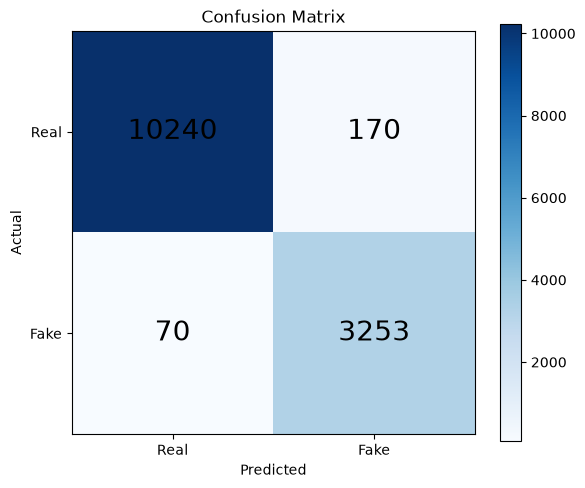

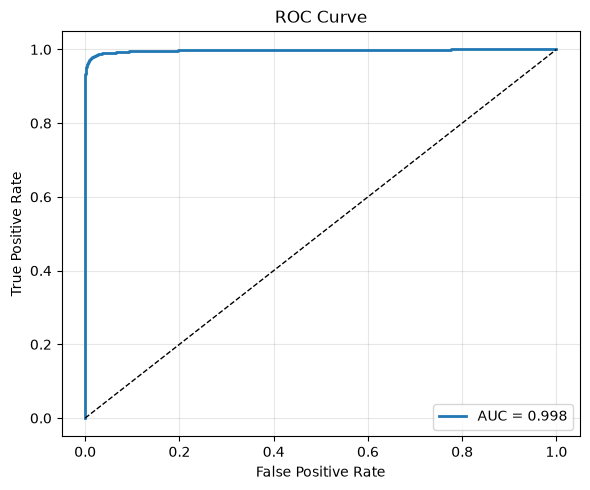


Final AUC Score: 0.9976

Saving models...
Models saved successfully!

Training Complete! Final AUC: 0.9976

Testing predictions on sample audio files

Real Audio Samples:
1. 16321.wav: Real (92.0% confidence)
2. 10988.wav: Real (99.3% confidence)
3. 4666.wav: Real (99.8% confidence)

Fake Audio Samples:
1. 19012.wav: Fake (75.0% confidence)
2. 3109.wav: Fake (100.0% confidence)
3. 2217.wav: Fake (100.0% confidence)

System ready for predictions!


In [10]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import xgboost as xgb
from tqdm import tqdm
import pickle
import shutil
import random
import glob

# Load and clean up audio files
def preprocess_audio(audio_path, target_sr=16000, duration=5.0):
    try:
        audio, sr = librosa.load(audio_path, sr=target_sr)
        audio, _ = librosa.effects.trim(audio, top_db=100)
        target_length = int(target_sr * duration)
        if len(audio) < target_length:
            # Fix: Use mode='wrap' instead of zero-padding to avoid artifacts
            pad_length = target_length - len(audio)
            audio = np.pad(audio, (0, pad_length), mode='wrap')
        else:
            audio = audio[:target_length]
        audio = audio / (np.max(np.abs(audio)) + 1e-9)
        return audio, target_sr
    except:
        return None, None

# Convert audio to mel spectrogram
def extract_mel_spectrogram(audio, sr):
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr, 
        n_mels=64,
        hop_length=1024
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

# Split our dataset into train, validation and test sets
def split_dataset(source_folder, dest_folder):
    print("\nSplitting dataset into train/val/test...")
    for split in ['train', 'val', 'test']:
        for cls in ['real', 'fake']:
            os.makedirs(os.path.join(dest_folder, split, cls), exist_ok=True)
    import pandas as pd
    meta_path = os.path.join(source_folder, 'meta.csv')
    df = pd.read_csv(meta_path)
    
    # Fix: Split by speaker to prevent data leakage
    speakers = df['speaker'].unique().tolist()
    import random
    random.shuffle(speakers)
    
    n_speakers = len(speakers)
    train_end = int(0.7 * n_speakers)
    val_end = int(0.85 * n_speakers)
    
    train_speakers = set(speakers[:train_end])
    val_speakers = set(speakers[train_end:val_end])
    test_speakers = set(speakers[val_end:])
    
    # Assign files to splits based on speaker
    split_counts = {'train': {'real': 0, 'fake': 0}, 'val': {'real': 0, 'fake': 0}, 'test': {'real': 0, 'fake': 0}}
    
    import shutil
    for _, row in df.iterrows():
        speaker = row['speaker']
        filename = row['file']
        label = row['label']
        cls = 'fake' if label == 'spoof' else 'real'
        
        if speaker in train_speakers:
            split = 'train'
        elif speaker in val_speakers:
            split = 'val'
        else:
            split = 'test'
            
        src_path = os.path.join(source_folder, filename)
        if os.path.exists(src_path):
            shutil.copy(src_path, os.path.join(dest_folder, split, cls, filename))
            split_counts[split][cls] += 1
    print("Splits generated based on speaker identities:")
    for split in ['train', 'val', 'test']:
        print(f"{split.capitalize()}: Real={split_counts[split]['real']}, Fake={split_counts[split]['fake']}")

# Helper to add noise
def augment_with_noise(audio, snr_range=(15, 40)):
    snr_db = np.random.uniform(*snr_range)
    signal_power = np.mean(audio ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(audio))
    return audio + noise

# Load audio files and convert them to spectrograms (Now with Augmentation!)
def load_spectrograms(data_dir, split, augment=False):
    X, y = [], []
    
    for label, cls in enumerate(['real', 'fake']):
        folder = os.path.join(data_dir, split, cls)
        files = [f for f in os.listdir(folder) if f.endswith(('.wav', '.mp3', '.flac'))]
        
        for f in tqdm(files, desc=f"Loading {split}/{cls}"):
            audio, sr = preprocess_audio(os.path.join(folder, f))
            if audio is not None:
                # If augmentation is enabled, 50% chance to add noise
                if augment and np.random.random() > 0.5:
                    audio = augment_with_noise(audio, snr_range=(15, 35))
                    
                spec = extract_mel_spectrogram(audio, sr)
                spec = np.expand_dims(spec, axis=-1)
                X.append(spec)
                y.append(label)
    
    return np.array(X), np.array(y)


# Build our CNN model
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # First convolutional block
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Second convolutional block
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Extract features
    x = layers.GlobalAveragePooling2D()(x)
    embeddings = layers.Dense(128, activation='relu', name='embeddings')(x)
    x = layers.Dropout(0.5)(embeddings)
    
    # Final classification
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Train the CNN
def train_cnn(X_train, y_train, X_val, y_val):
    print("\nTraining CNN model...")
    
    model = build_cnn(X_train.shape[1:])
    
    # Define early stopping to prevent overtraining
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3, 
        restore_best_weights=True,
        verbose=1
    )
    
    # Reduce learning rate when stuck
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    return model, history

# Extract embeddings from CNN in batches to avoid memory issues
def extract_embeddings(cnn_model, X, batch_size=32):
    embedding_model = keras.Model(
        inputs=cnn_model.input,
        outputs=cnn_model.get_layer('embeddings').output
    )
    
    embeddings = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    print(f"Extracting embeddings from {len(X)} samples...")
    for i in tqdm(range(0, len(X), batch_size)):
        batch = X[i:i+batch_size]
        batch_embeddings = embedding_model.predict(batch, verbose=0)
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)

# Train XGBoost classifier on the CNN embeddings
def train_xgboost(X_train, y_train, X_val, y_val):
    print("\nTraining XGBoost classifier...")
    
    model = xgb.XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        random_state=42,
        early_stopping_rounds=10
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=True
    )
    
    return model

# Evaluate our hybrid model
def evaluate_hybrid_model(cnn_model, xgb_model, X_test, y_test):
    print("\nEvaluating model on test set...")
    
    # Get embeddings from CNN
    embeddings = extract_embeddings(cnn_model, X_test)
    
    # Make predictions
    y_pred_proba = xgb_model.predict_proba(embeddings)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Print classification results
    print("\nResults:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=20)
    plt.xticks([0, 1], ['Real', 'Fake'])
    plt.yticks([0, 1], ['Real', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png')
    plt.show()
    
    print(f"\nFinal AUC Score: {roc_auc:.4f}")
    return roc_auc

# Main training pipeline
def main():
    print("="*60)
    print("Audio Deepfake Detection System")
    print("Hybrid CNN + XGBoost Model")
    print("="*60)
    
    # Download dataset
        # Use local dataset
    source_folder = 'release_in_the_wild'
    dest_folder = 'processed_data'

    
    # Split the dataset
    split_dataset(source_folder, dest_folder)
    
    # Load spectrograms
    print("\nLoading spectrograms...")
    X_train, y_train = load_spectrograms(dest_folder, 'train', augment=True)
    X_val, y_val = load_spectrograms(dest_folder, 'val')
    X_test, y_test = load_spectrograms(dest_folder, 'test')
    
    print(f"\nDataset loaded:")
    print(f"  Training: {X_train.shape}")
    print(f"  Validation: {X_val.shape}")
    print(f"  Test: {X_test.shape}")
    
    # Train CNN
    cnn_model, history = train_cnn(X_train, y_train, X_val, y_val)
    
    # Extract embeddings
    print("\nExtracting embeddings...")
    train_embeddings = extract_embeddings(cnn_model, X_train)
    val_embeddings = extract_embeddings(cnn_model, X_val)
    print(f"Embedding dimension: {train_embeddings.shape}")
    
    # Train XGBoost
    xgb_model = train_xgboost(train_embeddings, y_train, val_embeddings, y_val)
    
    # Evaluate
    auc_score = evaluate_hybrid_model(cnn_model, xgb_model, X_test, y_test)
    
    # Save models
    print("\nSaving models...")
    cnn_model.save('cnn_model.keras')
    with open('xgb_model.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
    print("Models saved successfully!")
    
    print("\n" + "="*60)
    print(f"Training Complete! Final AUC: {auc_score:.4f}")
    print("="*60)
    
    return cnn_model, xgb_model

# Predict if an audio file is real or fake
def predict_audio(audio_path, cnn_model, xgb_model):
    # Load and preprocess audio
    audio, sr = preprocess_audio(audio_path)
    if audio is None:
        return None, None
    
    # Convert to spectrogram
    spec = extract_mel_spectrogram(audio, sr)
    spec = np.expand_dims(spec, axis=(0, -1))
    
    # Get embedding from CNN
    embedding_model = keras.Model(
        inputs=cnn_model.input,
        outputs=cnn_model.get_layer('embeddings').output
    )
    embedding = embedding_model.predict(spec, verbose=0)
    
    # Predict with XGBoost
    prob = xgb_model.predict_proba(embedding)[0, 1]
    
    label = 'Fake' if prob > 0.5 else 'Real'
    confidence = prob * 100 if label == 'Fake' else (1 - prob) * 100
    
    return label, confidence

# Run everything
if __name__ == "__main__":
    # Train the model
    cnn_model, xgb_model = main()
    
    # Test predictions on some sample files
    print("\n" + "="*60)
    print("Testing predictions on sample audio files")
    print("="*60)
    
    real_files = glob.glob('processed_data/test/real/*.wav')[:3]
    fake_files = glob.glob('processed_data/test/fake/*.wav')[:3]
    
    print("\nReal Audio Samples:")
    for i, audio_path in enumerate(real_files, 1):
        label, conf = predict_audio(audio_path, cnn_model, xgb_model)
        filename = os.path.basename(audio_path)
        print(f"{i}. {filename}: {label} ({conf:.1f}% confidence)")
    
    print("\nFake Audio Samples:")
    for i, audio_path in enumerate(fake_files, 1):
        label, conf = predict_audio(audio_path, cnn_model, xgb_model)
        filename = os.path.basename(audio_path)
        print(f"{i}. {filename}: {label} ({conf:.1f}% confidence)")
    
    print("\n" + "="*60)
    print("System ready for predictions!")
    print("="*60)

=== FAKE AUDIO GRAD-CAM ===


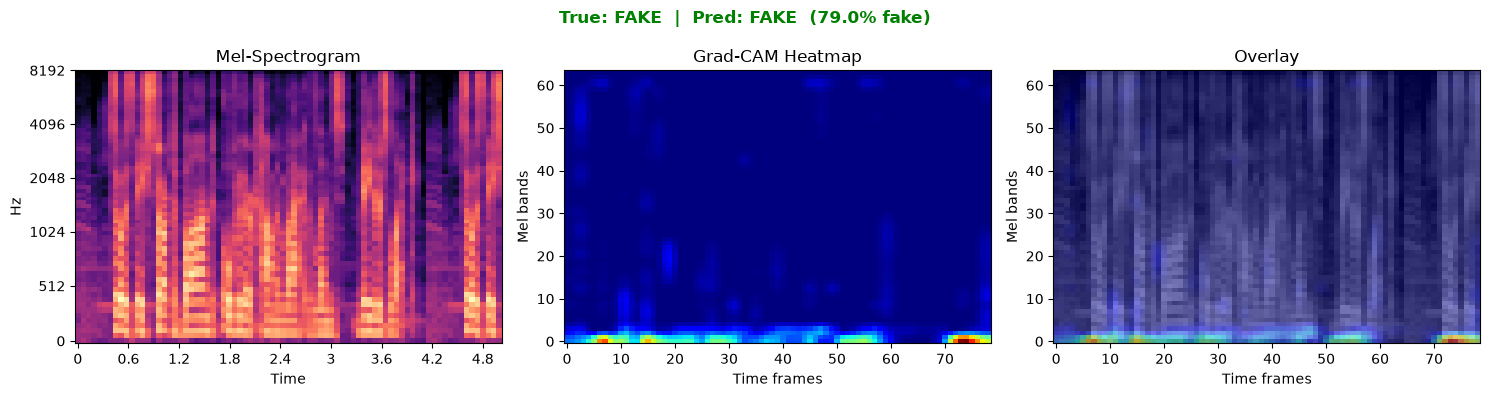

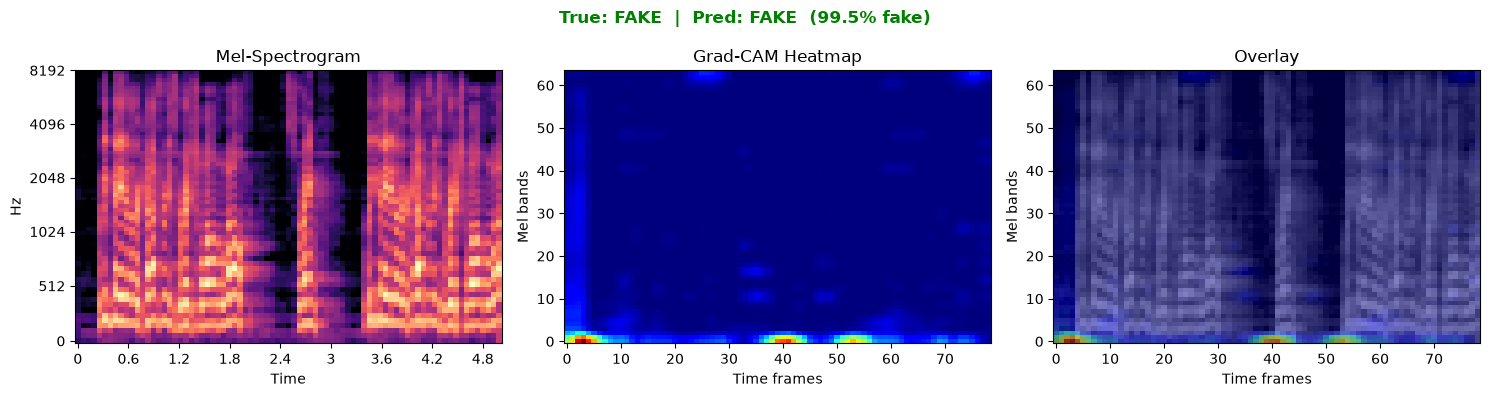

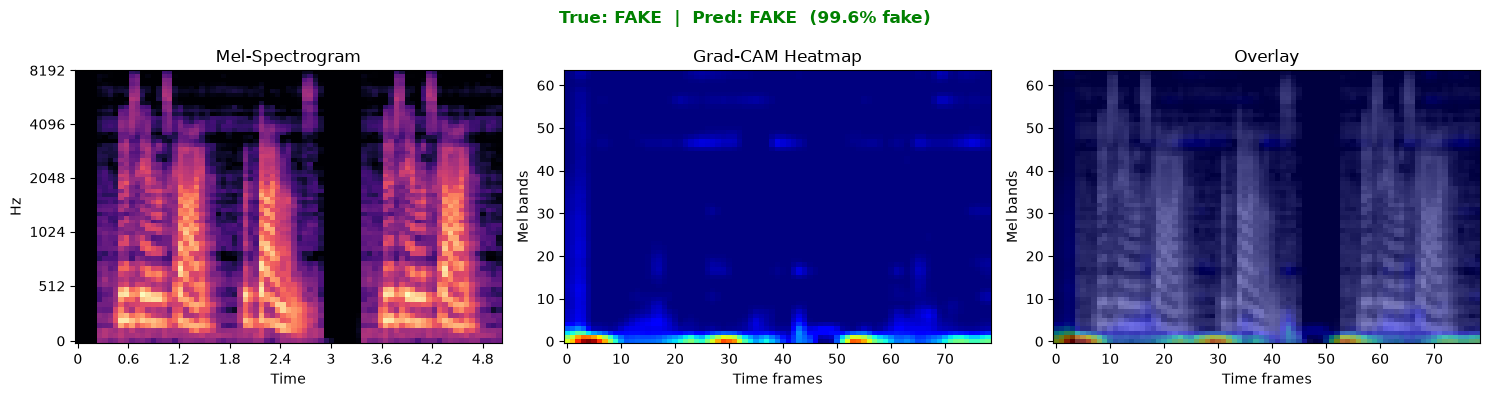


=== REAL AUDIO GRAD-CAM ===


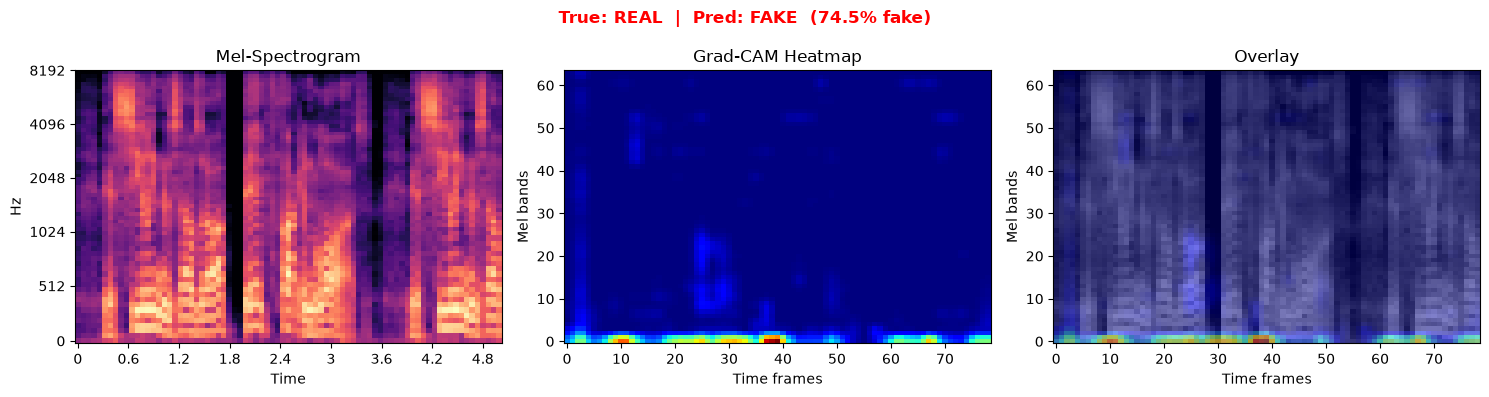

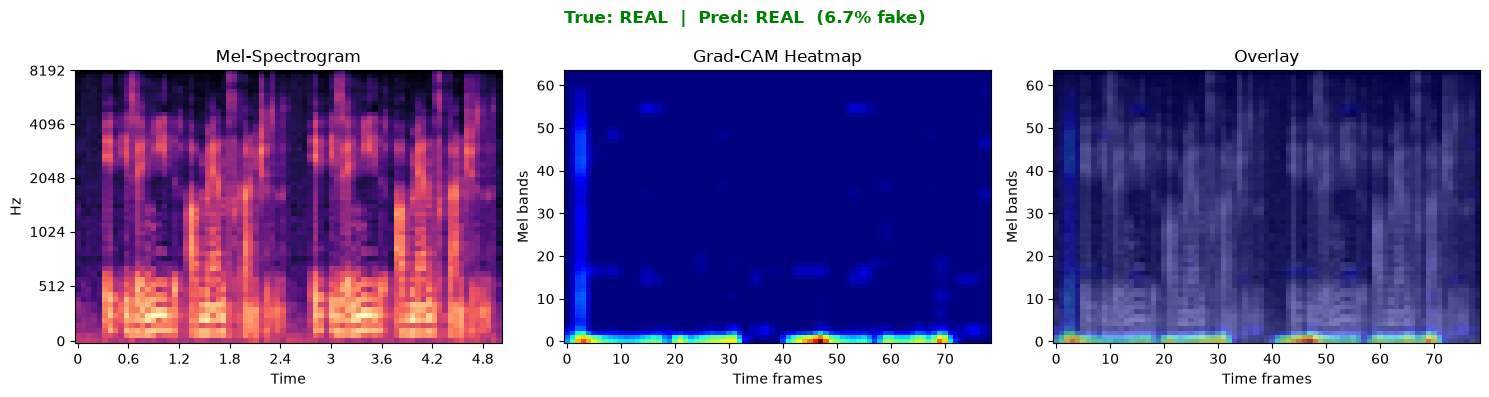

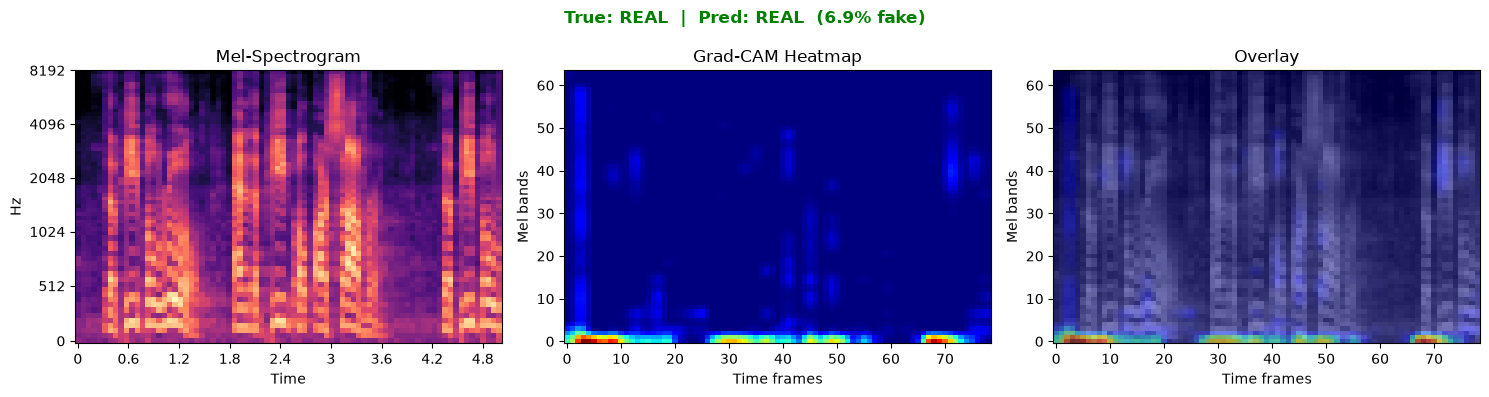

Analyzing 30 real files...
Analyzing 30 fake files...


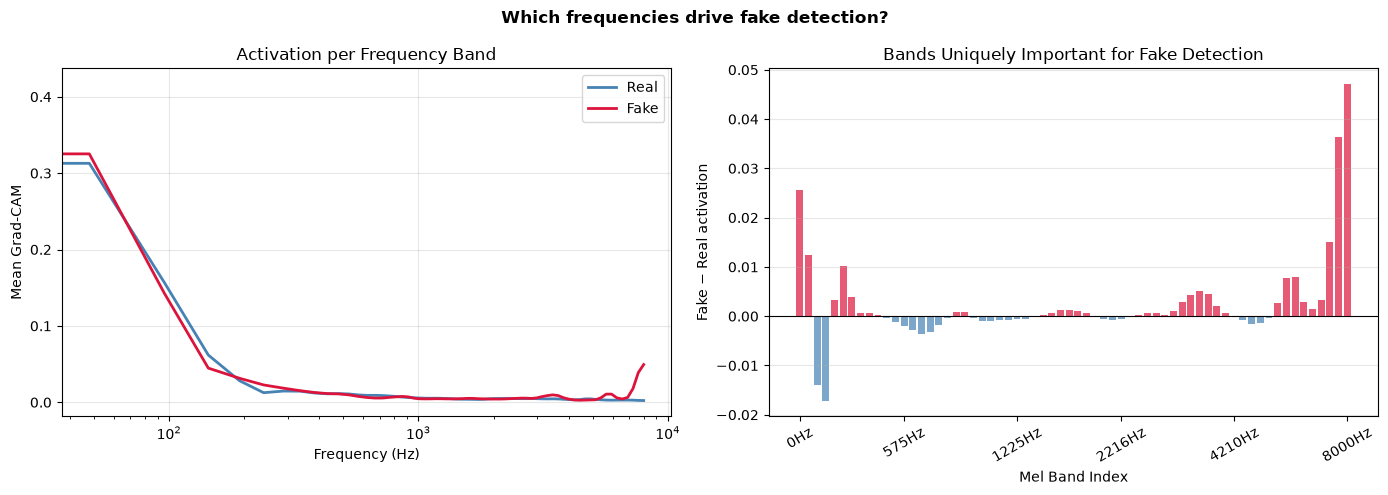


Top 5 frequency bands most activated for FAKE detection:
  Band  63  ~  8000 Hz   diff=+0.0471
  Band  62  ~  7615 Hz   diff=+0.0364
  Band   0  ~     0 Hz   diff=+0.0256
  Band  61  ~  7248 Hz   diff=+0.0150
  Band   1  ~    48 Hz   diff=+0.0124


In [ ]:
# %load gradcam_notebook.py

# Core Grad-CAM function ────────────────────────────────────

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None):
    # Automatically find the last Conv2D layer in the model!
    if last_conv_layer_name is None:
        last_conv_layer_name = [layer.name for layer in model.layers if isinstance(layer, keras.layers.Conv2D)][-1]
        
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        pred_prob = float(predictions[0][0])
        class_channel = predictions[:, 0]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_prob
# ── Visualization helper (Now fully dynamic) ───────────────────────────
def visualize_gradcam(audio_path, cnn_model, true_label_str="fake",
                      last_conv_layer=None):
    """Quick visualization for one audio file. true_label_str: 'real' or 'fake'"""
    audio, sr = preprocess_audio(audio_path)
    if audio is None:
        print("Could not load audio"); return
    spec = extract_mel_spectrogram(audio, sr)
    tensor = np.expand_dims(spec, axis=(0, -1))
    heatmap, pred_prob = make_gradcam_heatmap(tensor, cnn_model, last_conv_layer)
    pred_label = "FAKE" if pred_prob > 0.5 else "REAL"
    # Resize heatmap to spectrogram dimensions
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], [spec.shape[0], spec.shape[1]]
    ).numpy()[..., 0]
    # Build overlay
    spec_norm = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
    spec_rgb = np.stack([spec_norm]*3, axis=-1)
    colormap = plt.get_cmap('jet')
    heatmap_colored = colormap(heatmap_resized)[..., :3]
    overlay = np.clip(0.5 * spec_rgb + 0.5 * heatmap_colored, 0, 1)
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f"True: {true_label_str.upper()}  |  Pred: {pred_label}  "
        f"({pred_prob*100:.1f}% fake)",
        fontsize=12, fontweight='bold',
        color='green' if pred_label.lower() == true_label_str else 'red'
    )
    import librosa.display
    librosa.display.specshow(spec, sr=sr, hop_length=1024,
                              x_axis='time', y_axis='mel',
                              ax=axes[0], cmap='magma')
    axes[0].set_title("Mel-Spectrogram")
    axes[1].imshow(heatmap_resized, cmap='jet', aspect='auto', origin='lower')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].set_xlabel("Time frames"); axes[1].set_ylabel("Mel bands")
    axes[2].imshow(overlay, aspect='auto', origin='lower')
    axes[2].set_title("Overlay")
    axes[2].set_xlabel("Time frames"); axes[2].set_ylabel("Mel bands")
    plt.tight_layout()
    plt.show()


# Example: visualize one fake and one real file
# Run on a few test files ───────────────────────────────────

import os

test_fake_dir = "processed_data/test/fake"
test_real_dir = "processed_data/test/real"

fake_files = [f for f in os.listdir(test_fake_dir) if f.endswith('.wav')][:3]
real_files = [f for f in os.listdir(test_real_dir) if f.endswith('.wav')][:3]

print("=== FAKE AUDIO GRAD-CAM ===")
for f in fake_files:
    visualize_gradcam(
        os.path.join(test_fake_dir, f),
        cnn_model,           
        true_label_str="fake"
        # Notice we deleted the last_conv_layer line here!
    )

print("\n=== REAL AUDIO GRAD-CAM ===")
for f in real_files:
    visualize_gradcam(
        os.path.join(test_real_dir, f),
        cnn_model,
        true_label_str="real"
        # And deleted it here!
    )

#Frequency band analysis ───────────────────────────────────

def frequency_band_analysis(test_dir, cnn_model, n_per_class=30,
                             n_mels=64, sr=16000):
    """
    For n_per_class real and fake files, compute mean Grad-CAM
    activation per mel band. Reveals which frequencies drive detection.
    """
    real_acts, fake_acts = [], []
    mel_freqs = librosa.mel_frequencies(n_mels=n_mels, fmin=0, fmax=sr//2)

    for cls, label, store in [('real', 0, real_acts), ('fake', 1, fake_acts)]:
        folder = os.path.join(test_dir, cls)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')][:n_per_class]
        print(f"Analyzing {len(files)} {cls} files...")

        for fname in files:
            audio, sr_ = preprocess_audio(os.path.join(folder, fname))
            if audio is None: continue
            spec = extract_mel_spectrogram(audio, sr_)
            tensor = np.expand_dims(spec, axis=(0, -1))
            heatmap, _ = make_gradcam_heatmap(tensor, cnn_model)
            hm = tf.image.resize(heatmap[..., np.newaxis],
                                  [n_mels, heatmap.shape[1]]).numpy()[..., 0]
            store.append(hm.mean(axis=1))   # mean over time

    real_mean = np.array(real_acts).mean(axis=0)
    fake_mean = np.array(fake_acts).mean(axis=0)
    diff = fake_mean - real_mean

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Which frequencies drive fake detection?",
                 fontsize=12, fontweight='bold')

    axes[0].plot(mel_freqs, real_mean, label='Real', color='steelblue', lw=2)
    axes[0].plot(mel_freqs, fake_mean, label='Fake', color='crimson',   lw=2)
    axes[0].set_xlabel("Frequency (Hz)"); axes[0].set_ylabel("Mean Grad-CAM")
    axes[0].set_title("Activation per Frequency Band")
    axes[0].set_xscale('log'); axes[0].legend(); axes[0].grid(alpha=0.3)

    colors = ['crimson' if d > 0 else 'steelblue' for d in diff]
    axes[1].bar(range(n_mels), diff, color=colors, alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xlabel("Mel Band Index")
    axes[1].set_ylabel("Fake − Real activation")
    axes[1].set_title("Bands Uniquely Important for Fake Detection")
    tick_idx = np.linspace(0, n_mels-1, 6, dtype=int)
    axes[1].set_xticks(tick_idx)
    axes[1].set_xticklabels([f"{mel_freqs[i]:.0f}Hz" for i in tick_idx], rotation=30)
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("frequency_analysis.png", dpi=150)
    plt.show()

    top5 = np.argsort(diff)[::-1][:5]
    print("\nTop 5 frequency bands most activated for FAKE detection:")
    for i in top5:
        print(f"  Band {i:3d}  ~{mel_freqs[i]:6.0f} Hz   diff={diff[i]:+.4f}")


# Run frequency analysis
frequency_band_analysis("processed_data/test", cnn_model, n_per_class=30)


In [16]:
# %load robustness_test.py
import os
import glob
import random
import librosa
import subprocess
import numpy as np
import pickle
import tensorflow as tf
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm import tqdm

def compress_to_mp3_and_back(wav_path, bitrate="64k"):
    """Convert WAV → MP3 at given bitrate → WAV, return degraded audio."""
    mp3_path = wav_path.replace(".wav", f"_{bitrate}.mp3")
    out_path  = wav_path.replace(".wav", f"_{bitrate}_restored.wav")
    
    # WAV → MP3 (lossy compression)
    subprocess.run(["ffmpeg", "-i", wav_path, "-b:a", bitrate, 
                    mp3_path, "-y", "-loglevel", "quiet"])
    
    # MP3 → WAV (decode back, artifacts baked in)
    subprocess.run(["ffmpeg", "-i", mp3_path, out_path, 
                    "-y", "-loglevel", "quiet"])
    
    audio, sr = librosa.load(out_path, sr=16000)
    
    # Cleanup temporary files
    if os.path.exists(mp3_path): os.remove(mp3_path)
    if os.path.exists(out_path): os.remove(out_path)
        
    return audio

def add_gaussian_noise(audio, snr_db):
    """Add white noise at given SNR level."""
    signal_power = np.mean(audio ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(audio))
    return audio + noise

def process_and_predict(audio, embedding_model, xgb_model):
    """Trim, pad, extract mel-spectrogram, and run models to get probability."""
    audio, _ = librosa.effects.trim(audio, top_db=100)
    
    target_length = int(16000 * 5.0)
    if len(audio) < target_length:
        pad_length = target_length - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='wrap')
    else:
        audio = audio[:target_length]
        
    audio = audio / (np.max(np.abs(audio)) + 1e-9)
    
    spec = extract_mel_spectrogram(audio, 16000)
    spec = np.expand_dims(spec, axis=(0, -1))
    
    embedding = embedding_model.predict(spec, verbose=0)
    prob = xgb_model.predict_proba(embedding)[0][1]
    return prob

def evaluate_condition(files, labels, condition, embedding_model, xgb_model):
    y_true = []
    y_scores = []
    
    for f, label in zip(files, labels):
        try:
            if condition == "Clean":
                audio, _ = librosa.load(f, sr=16000)
            elif condition == "MP3 64kbps":
                audio = compress_to_mp3_and_back(f, "64k")
            elif condition == "MP3 128kbps":
                audio = compress_to_mp3_and_back(f, "128k")
            elif condition == "Noise SNR=10dB":
                audio, _ = librosa.load(f, sr=16000)
                audio = add_gaussian_noise(audio, 10)
            
            prob = process_and_predict(audio, embedding_model, xgb_model)
            y_true.append(label)
            y_scores.append(prob)
        except Exception as e:
            print(f"Error processing {f}: {e}")
        
    preds = [1 if p > 0.5 else 0 for p in y_scores]
    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, y_scores)
    return acc, auc, y_true, y_scores

if __name__ == "__main__":
    print("Loading models...")
    cnn_model = tf.keras.models.load_model('cnn_model.keras')
    embedding_model = tf.keras.Model(
        inputs=cnn_model.input,
        outputs=cnn_model.get_layer('embeddings').output
    )
    with open('xgb_model.pkl', 'rb') as f:
        xgb_model = pickle.load(f)
        
    real_files = glob.glob('processed_data/test/real/*.wav')
    fake_files = glob.glob('processed_data/test/fake/*.wav')
    
    random.seed(42)
    random.shuffle(real_files)
    random.shuffle(fake_files)
    
    # Use 250 real and 250 fake (500 total) for timely evaluation
    sample_size = min(250, len(real_files), len(fake_files))
    test_files = real_files[:sample_size] + fake_files[:sample_size]
    test_labels = [0]*sample_size + [1]*sample_size
    
    # Shuffle together
    combined = list(zip(test_files, test_labels))
    random.shuffle(combined)
    test_files, test_labels = zip(*combined)
    
    print(f"Evaluating {len(test_files)} samples...")
    
    results = {}
    conditions = ["Clean", "MP3 64kbps", "MP3 128kbps", "Noise SNR=10dB"]
    
    for cond in conditions:
        print(f"\nCondition: {cond}")
        acc, auc, y_true_cond, y_scores_cond = evaluate_condition(tqdm(test_files), test_labels, cond, embedding_model, xgb_model)
        
        if cond == "Noise SNR=10dB":
            thresholds = np.arange(0.1, 0.9, 0.02)
            f1_scores_list = []
            
            y_prob_noisy = np.array(y_scores_cond)
            y_true_noisy = np.array(y_true_cond)
            
            for t in thresholds:
                preds = (y_prob_noisy >= t).astype(int)
                f1 = f1_score(y_true_noisy, preds, zero_division=0)
                f1_scores_list.append(f1)
            
            best_threshold = thresholds[np.argmax(f1_scores_list)]
            best_f1 = max(f1_scores_list)
            print(f"\n--- F1 Optimization for Noise Condition ---")
            print(f"Optimal threshold under noise: {best_threshold:.2f}")
            print(f"F1 at optimal threshold: {best_f1:.3f}")
            
            best_preds = (y_prob_noisy >= best_threshold).astype(int)
            best_accuracy = np.mean(best_preds == y_true_noisy)
            print(f"Accuracy at optimal threshold: {best_accuracy:.3f}")
            print("-------------------------------------------\n")
            
            acc = best_accuracy
            
        results[cond] = (acc, auc)
        
    print("\n\n")
    print(f"{'Condition':<20} | {'Accuracy':<10} | {'AUC':<10}")
    print("-" * 50)
    for cond in conditions:
        acc, auc = results[cond]
        print(f"{cond:<20} | {acc*100:0.0f}%        | {auc:.3f}")
    print("="*50)


Loading models...
Evaluating 500 samples...

Condition: Clean


100%|██████████| 500/500 [00:11<00:00, 44.35it/s]



Condition: MP3 64kbps


100%|██████████| 500/500 [00:42<00:00, 11.77it/s]



Condition: MP3 128kbps


100%|██████████| 500/500 [00:42<00:00, 11.80it/s]



Condition: Noise SNR=10dB


100%|██████████| 500/500 [00:11<00:00, 42.56it/s]


--- F1 Optimization for Noise Condition ---
Optimal threshold under noise: 0.10
F1 at optimal threshold: 0.781
Accuracy at optimal threshold: 0.774
-------------------------------------------




Condition            | Accuracy   | AUC       
--------------------------------------------------
Clean                | 99%        | 1.000
MP3 64kbps           | 97%        | 0.993
MP3 128kbps          | 97%        | 0.993
Noise SNR=10dB       | 77%        | 0.864
